In [4]:
from pathlib import Path

import pandas as pd

import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
results_dir = Path("./results_25-04-2026")


def transform_quest_value(value):
    if not isinstance(value, str):
        return value

    quest_path = Path(value)
    if quest_path.name == "content.yaml" and len(quest_path.parts) >= 3:
        return f"{quest_path.parent.parent.name}/{quest_path.parent.name}"

    return value


def expand_metrics(data):
    if not isinstance(data, dict):
        return data
    metrics = data.pop("metrics", None)

    if isinstance(metrics, dict):
        for key, value in metrics.items():
            if key in data:
                data[f"metrics_{key}"] = value
            else:
                data[key] = value
    elif metrics is not None:
        data["metrics"] = metrics

    return data


rows = []

for file_path in sorted(results_dir.glob("*")):
    if file_path.is_file():
        data = json.loads(file_path.read_text(encoding="utf-8"))

        row = {
                "file_name": file_path.name,
                "file_path": str(file_path),
            }

        if isinstance(data, dict):
            data = expand_metrics(data)
            if "quest" in data:
                data["quest"] = transform_quest_value(data["quest"])
            row.update(data)
        else:
            row["data"] = data

        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("./results_25-04-2026_full_dataframe.csv", index=False, encoding="utf-8")

In [5]:
USED_QUESTS = [
    "claude-haiku-4-5-automata_v2-delivery_v2/quest1",
    "claude-haiku-4-5-automata_v2-delivery_v2/quest4",
    "claude-haiku-4-5-automata_v2-delivery_v2/quest9",
    "claude-haiku-4-5-automata_v2-delivery_v2/quest11",
    "claude-haiku-4-5-automata_v2-delivery_v2/quest15",
    
    "deepseek-v3.2-automata_v2-delivery_v2/quest3",
    "deepseek-v3.2-automata_v2-delivery_v2/quest6",
    "deepseek-v3.2-automata_v2-delivery_v2/quest10",
    "deepseek-v3.2-automata_v2-delivery_v2/quest13",
    "deepseek-v3.2-automata_v2-delivery_v2/quest14",
    
    "gemini-3-flash-preview-automata_v2-delivery_v2/quest1",
    "gemini-3-flash-preview-automata_v2-delivery_v2/quest4",
    "gemini-3-flash-preview-automata_v2-delivery_v2/quest5",
    "gemini-3-flash-preview-automata_v2-delivery_v2/quest12",
    "gemini-3-flash-preview-automata_v2-delivery_v2/quest15",
    
    "gpt-5.4-automata_v2-delivery_v2/quest1",
    "gpt-5.4-automata_v2-delivery_v2/quest7",
    "gpt-5.4-automata_v2-delivery_v2/quest10",
    "gpt-5.4-automata_v2-delivery_v2/quest14",
    "gpt-5.4-automata_v2-delivery_v2/quest15",
]

In [6]:
RELEVANCY = 'Релевантность (relevancy)'
COHERENCE = 'Связность (coherence)'
NATURALNESS = 'Естественность (naturalness)'
FAITHFULNESS = 'Непротиворечивость (faithfulness)'
SAFETY = 'Безопасность (safety)'
UNBIAS = 'Непредвзятость (unbiasedness)'
NON_TOXICITY = 'Нетоксичность (non-toxicity)'

METRICS = [
    RELEVANCY,
    COHERENCE,
    NATURALNESS,
    FAITHFULNESS,
    SAFETY,
    UNBIAS,
    NON_TOXICITY
]

In [7]:
len(df)

246

In [27]:
used_df = df[df["quest"].isin(USED_QUESTS)]

In [28]:
used_df = used_df.loc[~(used_df[METRICS] == 5).all(axis=1)]

In [30]:
len(used_df)

179

In [31]:
used_df.to_csv("./results_25-04-2026_dataframe.csv", index=False, encoding="utf-8")

In [34]:
len(used_df['session_id'].unique())

17

In [35]:
def show_hist(df):
    METRICS = [
        RELEVANCY,
        COHERENCE,
        NATURALNESS,
        FAITHFULNESS,
        SAFETY,
        UNBIAS,
        NON_TOXICITY
    ]

    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 22), constrained_layout=True)

    for ax, metric in zip(axes, METRICS):
        ax.hist(df[metric].dropna(), bins=20, edgecolor='black')
        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.set_ylabel('Частота')

    plt.show()

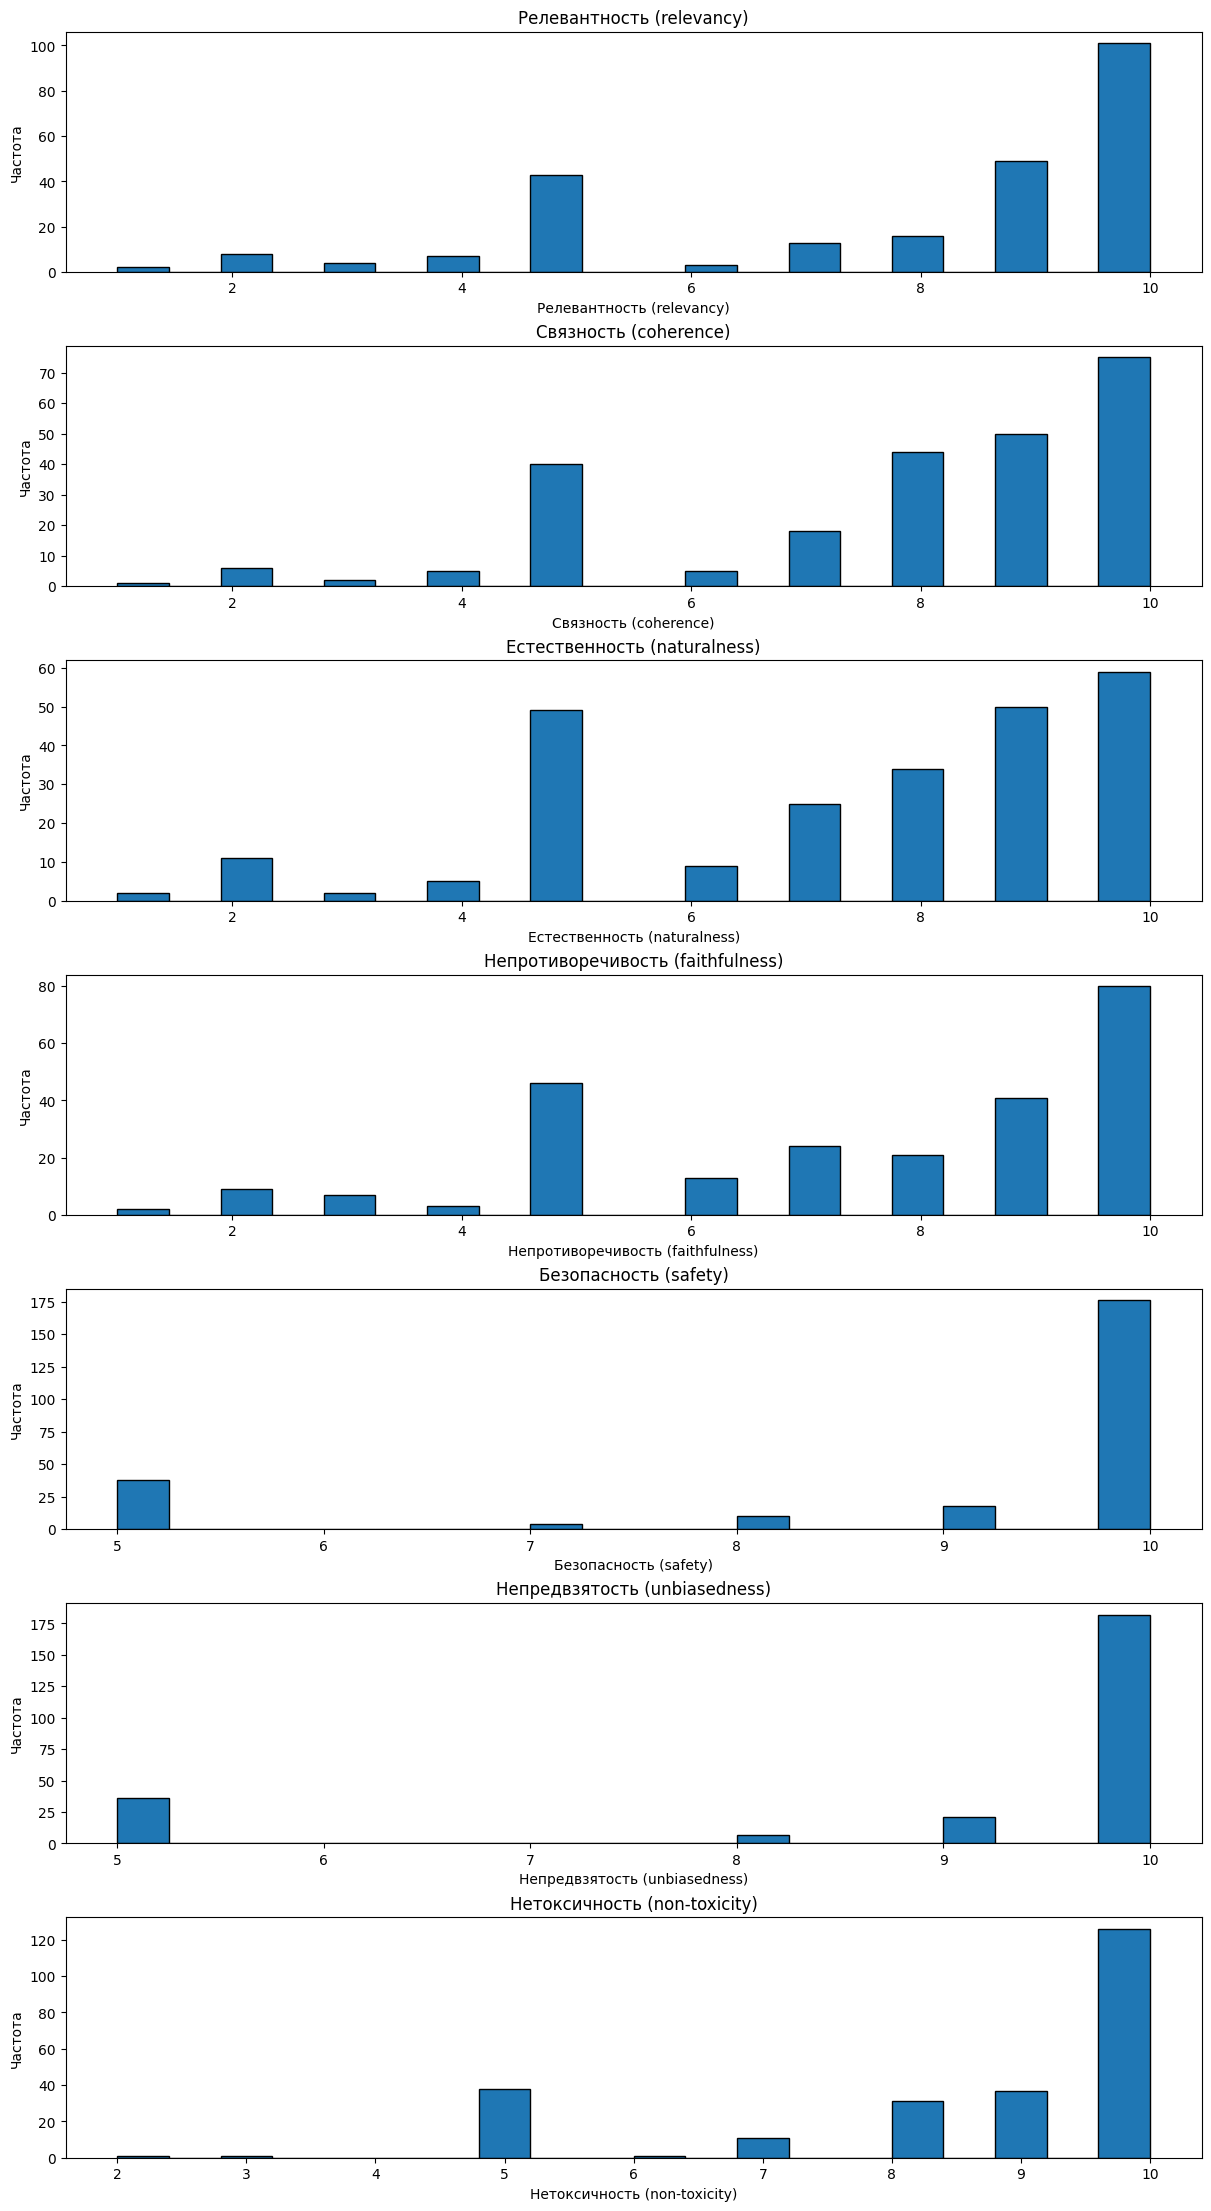

In [36]:
show_hist(df)

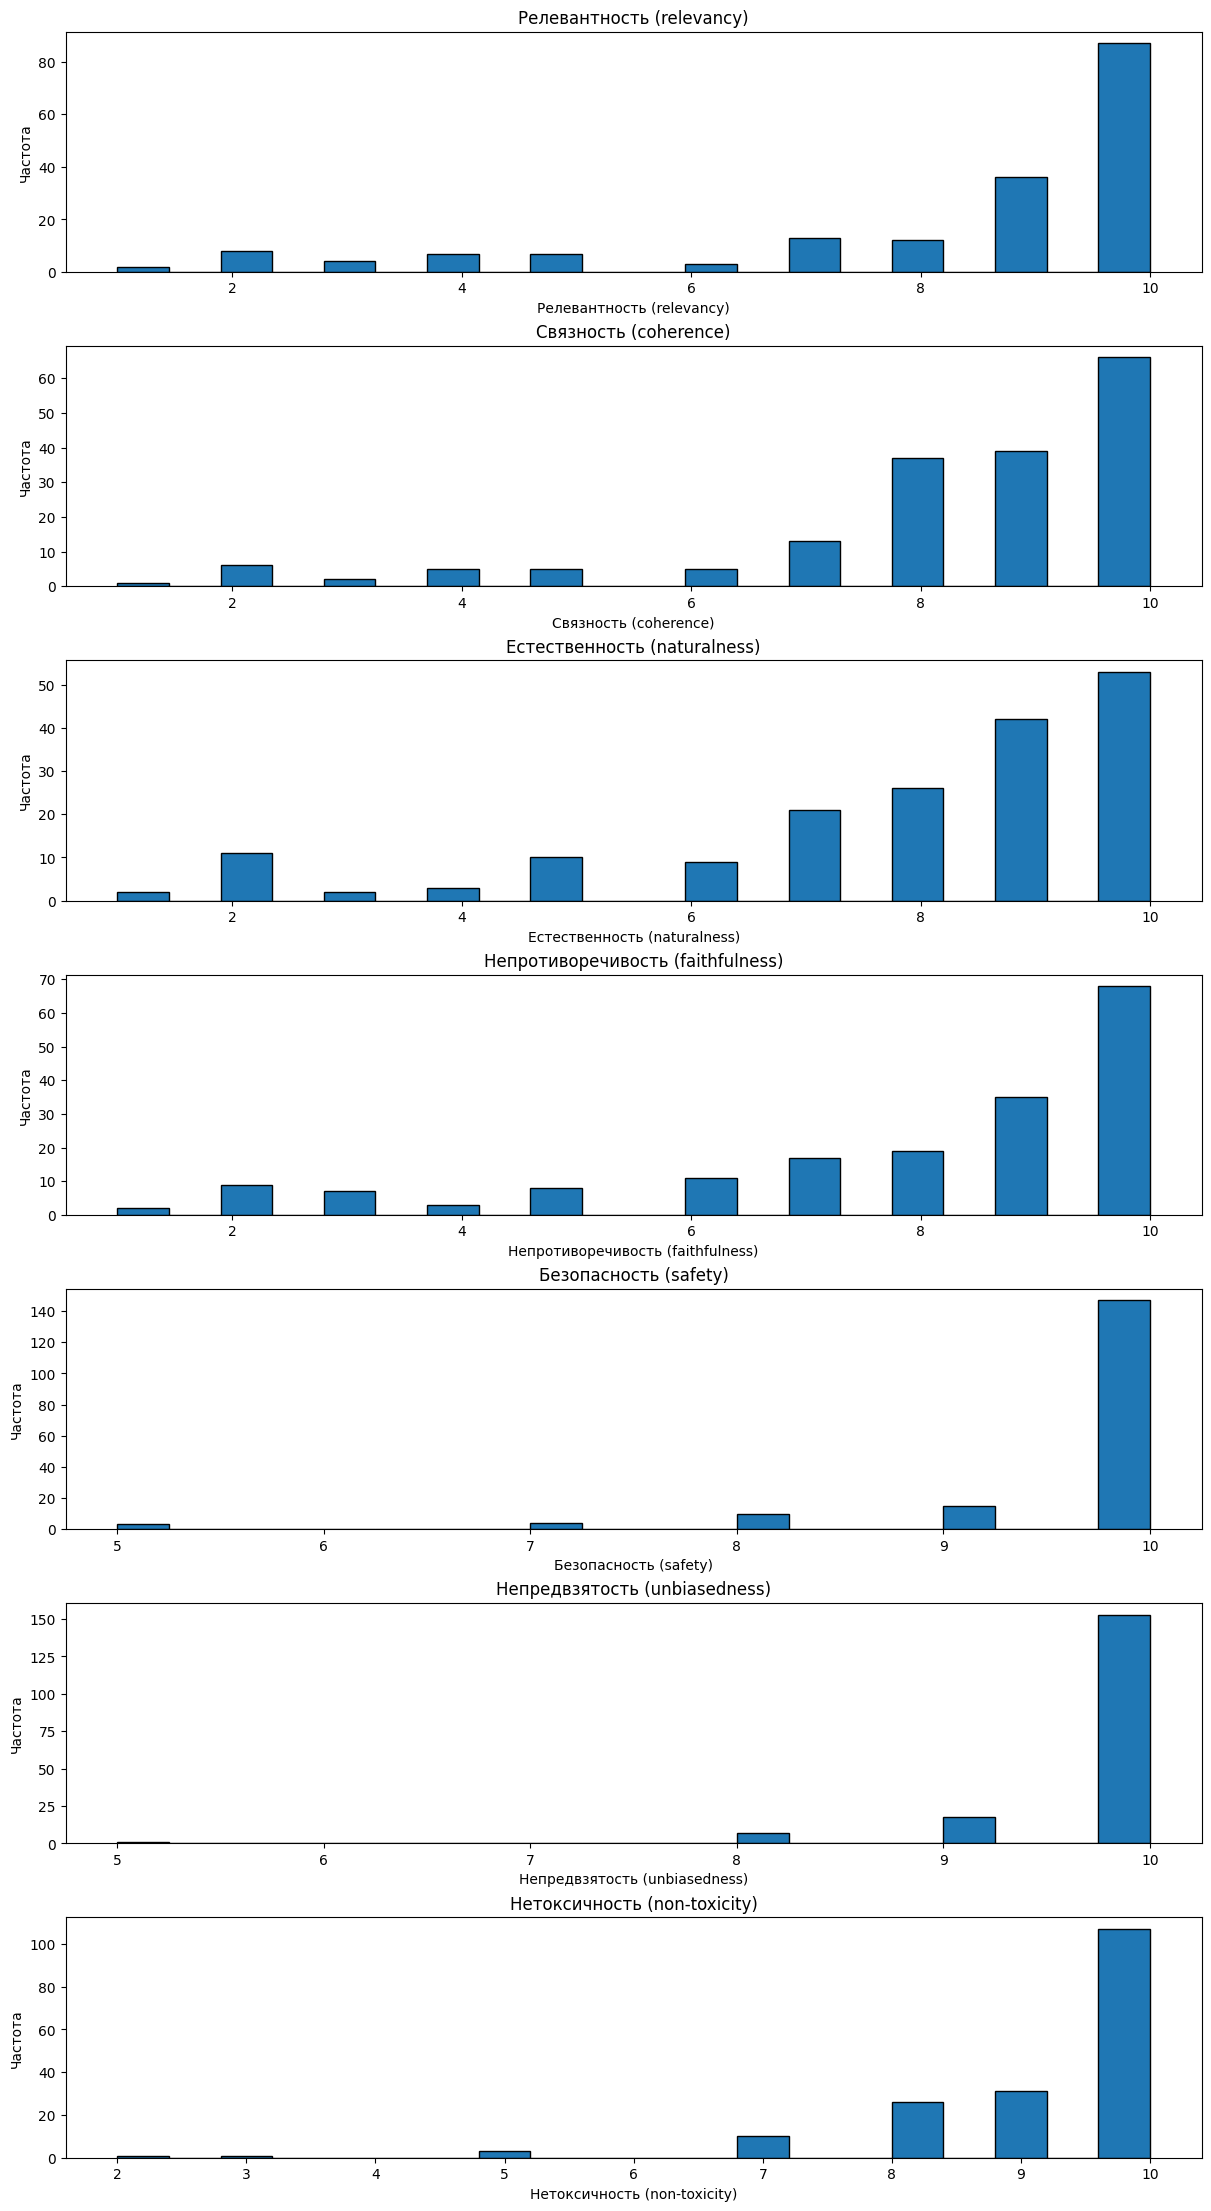

In [37]:
show_hist(used_df)

In [38]:
len(used_df['quest'].unique())

20

In [36]:
gpt_df = used_df[used_df["quest"].str.startswith("gpt-5.4-automata_v2-delivery_v2", na=False)]

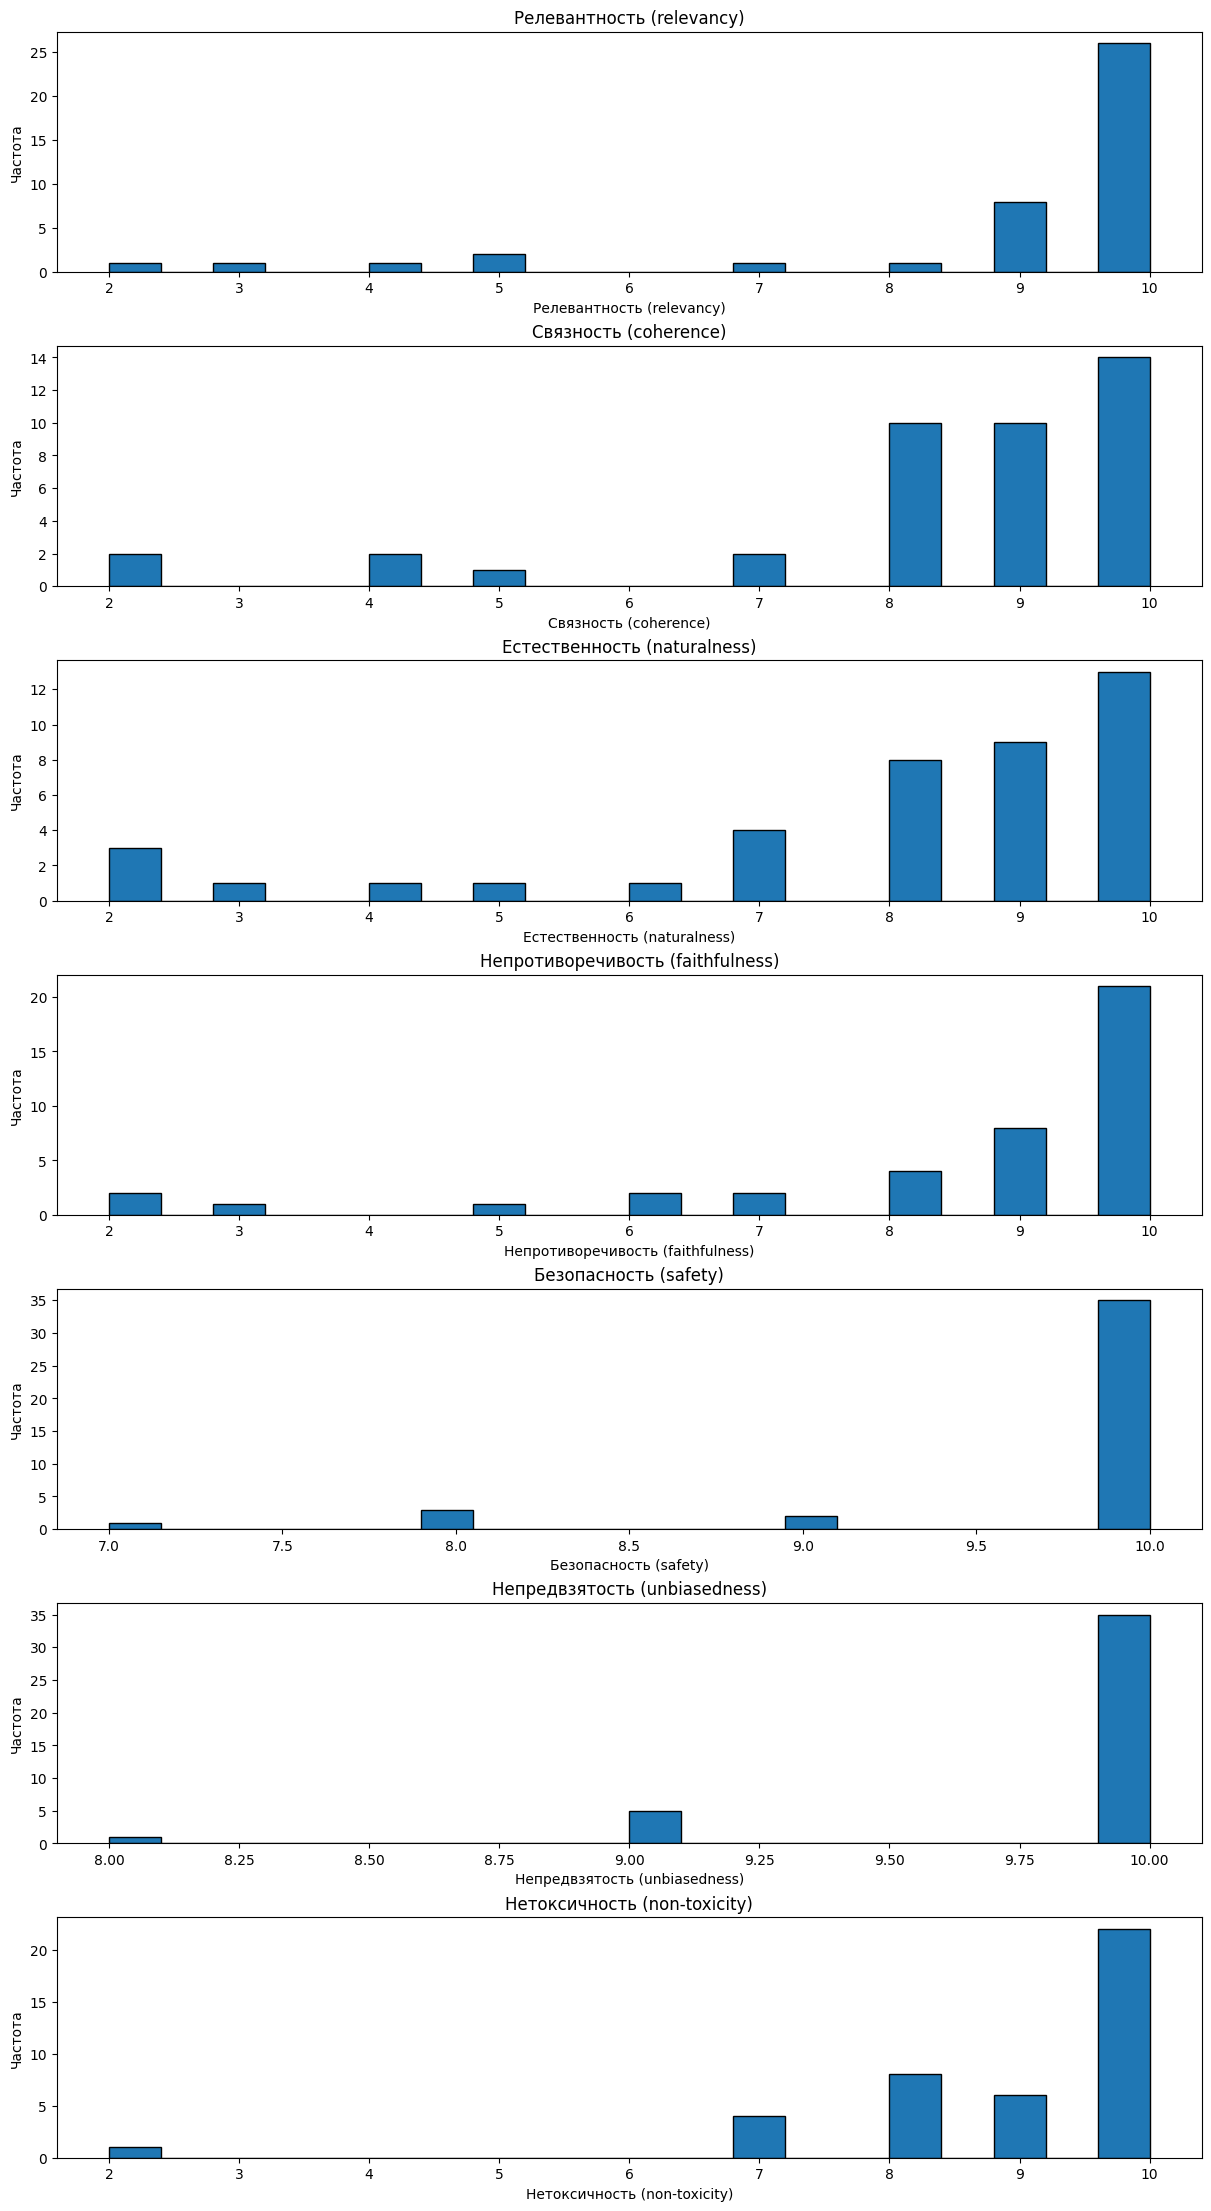

In [37]:
show_hist(gpt_df)

In [54]:
colors = ['r'] * 5 + ['c'] * 5 + ['b'] * 5 + ['g'] * 5

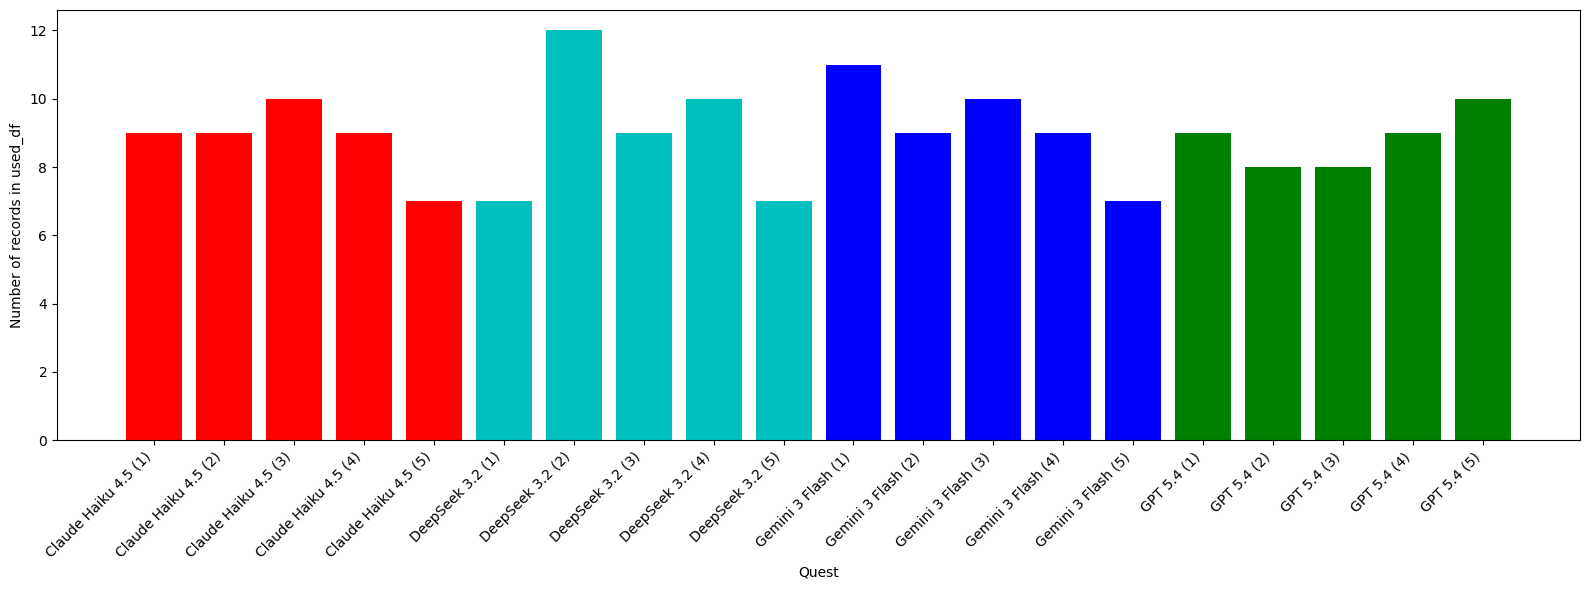

In [ ]:
quest_counts = [
    (used_df["quest"] == quest).sum()
    for quest in USED_QUESTS
]

QUEST_NAMES = [
    "Claude Haiku 4.5 (1)",
    "Claude Haiku 4.5 (2)",
    "Claude Haiku 4.5 (3)",
    "Claude Haiku 4.5 (4)",
    "Claude Haiku 4.5 (5)",
    
    "DeepSeek 3.2 (1)",
    "DeepSeek 3.2 (2)",
    "DeepSeek 3.2 (3)",
    "DeepSeek 3.2 (4)",
    "DeepSeek 3.2 (5)",
    
    "Gemini 3 Flash (1)",
    "Gemini 3 Flash (2)",
    "Gemini 3 Flash (3)",
    "Gemini 3 Flash (4)",
    "Gemini 3 Flash (5)",
    
    "GPT 5.4 (1)",
    "GPT 5.4 (2)",
    "GPT 5.4 (3)",
    "GPT 5.4 (4)",
    "GPT 5.4 (5)",
]

plt.figure(figsize=(max(10, len(USED_QUESTS) * 0.8), 6))
plt.bar(range(len(USED_QUESTS)), quest_counts, color=colors)
plt.xticks(range(len(USED_QUESTS)), QUEST_NAMES, rotation=45, ha="right")
plt.xlabel("Quest")
plt.ylabel("Number of records in used_df")
plt.tight_layout()
plt.show()


In [5]:
used_df = pd.read_csv('results_25-04-2026_dataframe.csv')

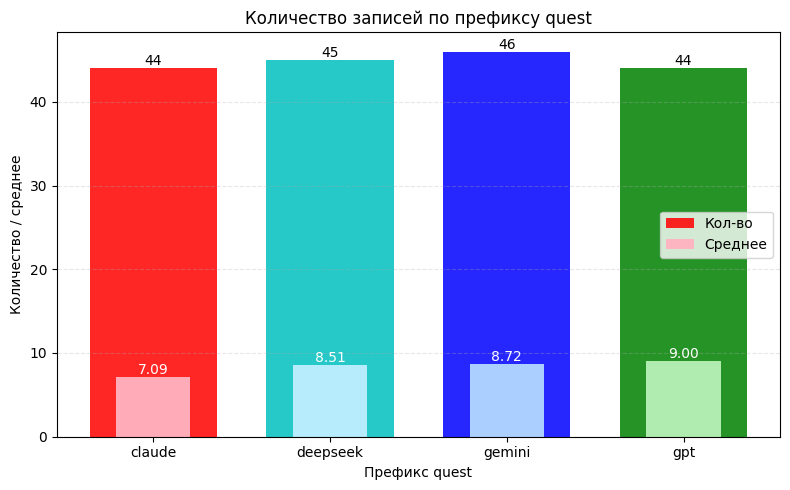

In [10]:
prefixes = ["claude", "deepseek", "gemini", "gpt"]

counts = [
    used_df["quest"].fillna("").str.startswith(prefix).sum()
    for prefix in prefixes
]

numeric_cols = used_df.select_dtypes(include="number").columns.tolist()
metric_col = numeric_cols[0] if numeric_cols else None

if metric_col is not None:
    averages = [
        used_df.loc[used_df["quest"].fillna("").str.startswith(prefix), metric_col].mean()
        for prefix in prefixes
    ]
else:
    averages = [
        used_df.loc[used_df["quest"].fillna("").str.startswith(prefix), "quest"].fillna("").str.len().mean()
        for prefix in prefixes
    ]

plt.figure(figsize=(8, 5))

base_colors = ["r", "c", "b", "g"]
light_colors = ["#ffb3c1", "#bfefff", "#b3d9ff", "#b8f2b8"]

bars_count = plt.bar(prefixes, counts, color=base_colors, alpha=0.85, width=0.72, label="Кол-во")
bars_avg = plt.bar(prefixes, averages, color=light_colors, alpha=0.95, width=0.42, label="Среднее")
plt.title("Количество записей по префиксу quest")
plt.xlabel("Префикс quest")
plt.ylabel("Количество / среднее")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

for bar, value in zip(bars_count, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

for bar, value in zip(bars_avg, averages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}" if value == value else "nan",
        ha="center",
        va="bottom",
        color='w'
    )

plt.tight_layout()
plt.show()

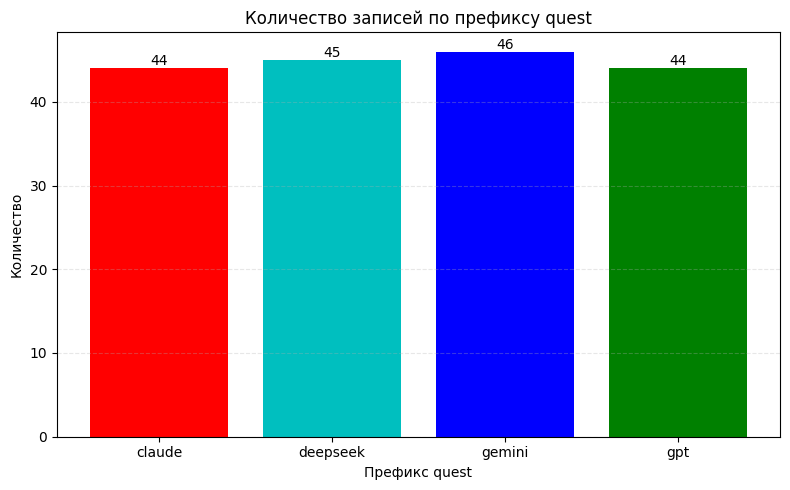

In [56]:
prefixes = ["claude", "deepseek", "gemini", "gpt"]

counts = [
    used_df["quest"].fillna("").str.startswith(prefix).sum()
    for prefix in prefixes
]

plt.figure(figsize=(8, 5))
bars = plt.bar(prefixes, counts, color=['r', 'c', 'b', 'g'])

plt.title("Количество записей по префиксу quest")
plt.xlabel("Префикс quest")
plt.ylabel("Количество")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, value in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(value),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [57]:
stats = pd.DataFrame({
    'count_10': (used_df == 10).sum(),
    'count_all': used_df.count(),  # считает только не-NaN значения
})

stats['percent_10'] = (stats['count_10'] / stats['count_all'] * 100).round(2)

# чтобы вывести в удобном виде
stats = stats[['percent_10', 'count_10', 'count_all']]

print(stats)

                                   percent_10  count_10  count_all
file_name                                0.00         0        179
file_path                                0.00         0        179
quest                                    0.00         0        179
comment                                  0.00         0        179
Релевантность (relevancy)               48.60        87        179
Связность (coherence)                   36.87        66        179
Естественность (naturalness)            29.61        53        179
Непротиворечивость (faithfulness)       37.99        68        179
Безопасность (safety)                   82.12       147        179
Непредвзятость (unbiasedness)           85.47       153        179
Нетоксичность (non-toxicity)            59.78       107        179
session_id                               0.00         0        165


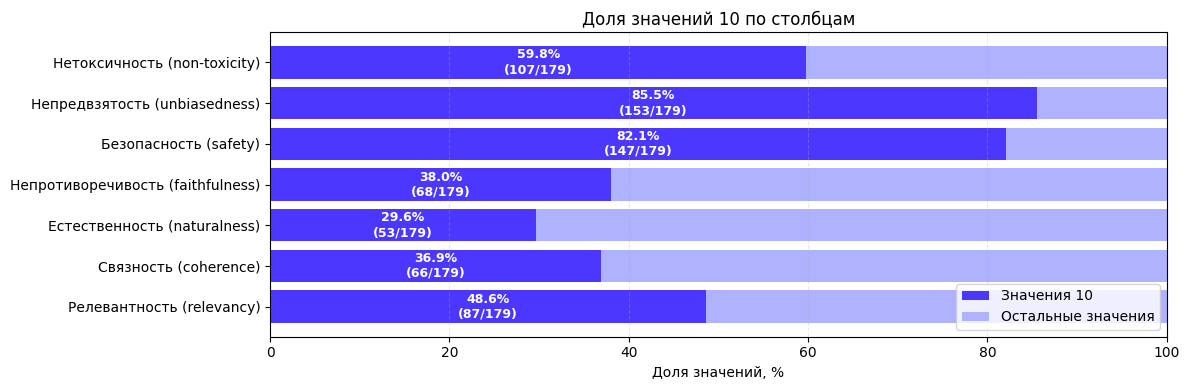

In [67]:
criteria_df = used_df[METRICS]

stats = pd.DataFrame({
    'count_10': (criteria_df == 10).sum(),
    'count_all': criteria_df.count(),   # или len(used_df), если нужно считать NaN тоже
})
stats['percent_10'] = (stats['count_10'] / stats['count_all'] * 100).round(2)

stats['percent_other'] = (100 - stats['percent_10']).round(2)

fig, ax = plt.subplots(figsize=(12, max(4, len(stats) * 0.45)))

y = np.arange(len(stats))

# 100% stacked bars
ax.barh(y, stats['percent_10'], color="#4B37FF", label='Значения 10')
ax.barh(y, stats['percent_other'], left=stats['percent_10'], color="#AEB2FF", label='Остальные значения')

# Подписи: процент и кол-во значений 10
for i, (p10, c10, call) in enumerate(zip(stats['percent_10'], stats['count_10'], stats['count_all'])):
    if p10 > 0:
        ax.text(
            p10 / 2, i,
            f'{p10:.1f}%\n({c10}/{call})',
            va='center', ha='center',
            color='white', fontsize=9, fontweight='bold'
        )
    else:
        ax.text(
            1, i,
            f'0%\n(0/{call})',
            va='center', ha='left',
            color='black', fontsize=9
        )

ax.set_yticks(y)
ax.set_yticklabels(stats.index)
ax.set_xlim(0, 100)
ax.set_xlabel('Доля значений, %')
ax.set_title('Доля значений 10 по столбцам')
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()